# Retrain PPG-BP Model with Custom ESP Data

This notebook:
1. Loads the original 56-subject dataset + preprocessing pipeline from the 2nd run
2. Loads 12 new subjects from your ESP module (~8 Hz)
3. Resamples new data to 100 Hz for pipeline compatibility
4. Extracts features using the same 57-feature pipeline
5. Retrains on combined 68-subject dataset
6. Exports lightweight model for ESP cloud deployment

In [1]:
!pip install -q mrmr-selection skrebate openpyxl gpytorch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 11.2 MB/s eta 0:00:00


In [2]:
import os, json, warnings, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import gpytorch
from scipy import signal as scipy_signal
from scipy.signal import savgol_filter, resample
from scipy.interpolate import interp1d
from scipy.stats import skew, kurtosis, entropy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.base import clone, BaseEstimator, RegressorMixin
import mrmr
from skrebate import ReliefF
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42.4 GB


## 1. Upload Data

Upload the following to Colab:
- `Our Dataset/` folder (12 CSV files) â€” or as a zip
- `SBP  DBP VALUES AND HR.txt`
- Original dataset `PPG_csv_info/` folder (56 subjects) â€” or download from GitHub

In [4]:
# Download original 56-subject dataset from GitHub
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/sanvsquezsz/PPG-based-BP-assessment/main"
ORIG_DIR = "PPG_csv_info"
os.makedirs(ORIG_DIR, exist_ok=True)

print("Downloading original 56-subject dataset...")
for i in range(1, 57):
    fname = f"PPG_subj_wInfo_{i:02d}.csv"
    url = f"{BASE_URL}/Dataset/PPG_csv_info/{fname}"
    dest = os.path.join(ORIG_DIR, fname)
    if not os.path.exists(dest):
        try:
            urllib.request.urlretrieve(url, dest)
        except Exception as e:
            print(f"  FAILED {fname}: {e}")

print(f"Original dataset: {len(os.listdir(ORIG_DIR))} files")

# Mount Google Drive for custom ESP data
from google.colab import drive
drive.mount("/content/drive")

CUSTOM_DIR = "/content/drive/MyDrive/NPU Project/BP Estimation Dataset"
print(f"Custom dataset dir exists: {os.path.exists(CUSTOM_DIR)}")
if os.path.exists(CUSTOM_DIR):
    csv_files = [f for f in os.listdir(CUSTOM_DIR) if f.endswith(".csv")]
    print(f"Custom dataset: {len(csv_files)} CSV files")
    for f in sorted(csv_files):
        print(f"  - {f}")


Original dataset: 56 files
Mounted at /content/drive
Custom dataset dir exists: True
Custom dataset: 14 CSV files
  - abdasim_processed_ppg_data.csv
  - abdullahmir_processed_ppg_data.csv
  - alimasoodkhan_processed_ppg_data.csv
  - amna_processed_ppg_data.csv
  - ayesha_processed_ppg_data.csv
  - fatima_processed_ppg_data.csv
  - hasnat_processed_ppg_data.csv
  - ibrahim_processed_ppg_data.csv
  - jalal_processed_ppg_data.csv
  - mahmad_processed_ppg_data.csv
  - ommama_processed_ppg_data.csv
  - sarahsohail_processed_ppg_data.csv
  - shameerashrafprocessed_ppg_data.csv
  - talhahassan_processed_ppg_data.csv


## 2. Preprocessing Pipeline (Same as 2nd Run)

In [5]:
# ============================
# Constants & Preprocessing
# ============================
FS = 100  # Target sampling frequency
WINDOW_SEC = 30
OVERLAP_SEC = 25
STEP_SEC = WINDOW_SEC - OVERLAP_SEC
WINDOW_SAMPLES = WINDOW_SEC * FS
STEP_SAMPLES = STEP_SEC * FS


def segment_signal(signal, window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES):
    segments = []
    start = 0
    while start + window_samples <= len(signal):
        segments.append(signal[start:start + window_samples])
        start += step_samples
    return segments


def chebyshev2_bandpass_filter(signal_data, lowcut=0.4, highcut=8.0, fs=FS, order=4, rs=40):
    nyq = fs / 2.0
    low = lowcut / nyq
    high = highcut / nyq
    b, a = scipy_signal.cheby2(order, rs, [low, high], btype='band')
    return scipy_signal.filtfilt(b, a, signal_data)


def normalize_signal(signal_data):
    sig_min, sig_max = np.min(signal_data), np.max(signal_data)
    if sig_max - sig_min == 0:
        return np.zeros_like(signal_data)
    return (signal_data - sig_min) / (sig_max - sig_min)


def compute_derivatives(signal_data):
    vpg = np.diff(signal_data)
    apg = np.diff(vpg)
    vpg = savgol_filter(vpg, window_length=11, polyorder=3)
    apg = savgol_filter(apg, window_length=11, polyorder=3)
    return vpg, apg


def preprocess_segment(segment):
    filtered = chebyshev2_bandpass_filter(segment)
    normalized = normalize_signal(filtered)
    vpg, apg = compute_derivatives(normalized)
    return normalized, vpg, apg


# ============================
# Feature Extraction (57 features)
# ============================
def kaiser_teager_energy(x):
    return x[1:-1]**2 - x[:-2] * x[2:]

def shannon_entropy(x, n_bins=50):
    hist, _ = np.histogram(x, bins=n_bins, density=True)
    hist = hist[hist > 0]
    p = hist / hist.sum()
    return -np.sum(p * np.log2(p))

def zero_crossing_rate(x):
    x_centered = x - np.mean(x)
    return np.sum(np.abs(np.diff(np.sign(x_centered))) > 0) / len(x)

def extract_features_from_signal(sig, prefix):
    f = {}
    f[f'mu({prefix})'] = np.mean(sig)
    f[f'eta({prefix})'] = np.median(sig)
    f[f'sigma({prefix})'] = np.std(sig)
    f[f'sigma2({prefix})'] = np.var(sig)
    f[f'IQR({prefix})'] = np.percentile(sig, 75) - np.percentile(sig, 25)
    f[f'skew({prefix})'] = skew(sig)
    f[f'kurt({prefix})'] = kurtosis(sig)
    f[f'ZCR({prefix})'] = zero_crossing_rate(sig)
    f[f'H({prefix})'] = shannon_entropy(sig)
    energy = sig ** 2
    f[f'E_mu({prefix})'] = np.mean(energy)
    f[f'E_sigma2({prefix})'] = np.var(energy)
    f[f'E_skew({prefix})'] = skew(energy)
    f[f'E_kurt({prefix})'] = kurtosis(energy)
    f[f'E_IQR({prefix})'] = np.percentile(energy, 75) - np.percentile(energy, 25)
    kte = kaiser_teager_energy(sig)
    f[f'KTE_mu({prefix})'] = np.mean(kte)
    f[f'KTE_sigma2({prefix})'] = np.var(kte)
    f[f'KTE_skew({prefix})'] = skew(kte)
    f[f'KTE_kurt({prefix})'] = kurtosis(kte)
    f[f'KTE_IQR({prefix})'] = np.percentile(kte, 75) - np.percentile(kte, 25)
    return f

def extract_all_features(ppg, vpg, apg):
    features = {}
    features.update(extract_features_from_signal(ppg, 'PPG'))
    features.update(extract_features_from_signal(vpg, 'VPG'))
    features.update(extract_features_from_signal(apg, 'APG'))
    return features

print("Pipeline ready. 57 features per segment.")

Pipeline ready. 57 features per segment.


## 3. Load Original 56-Subject Dataset

In [6]:
# Load original dataset
orig_subjects = []
for i in range(1, 57):
    fname = os.path.join(ORIG_DIR, f"PPG_subj_wInfo_{i:02d}.csv")
    if os.path.exists(fname):
        with open(fname, 'r') as f:
            raw_line = f.read().strip()
        parts = raw_line.split(',')
        orig_subjects.append({
            'id': parts[0],
            'age': int(parts[1]),
            'gender': parts[2],
            'sys_BP': int(parts[5]),
            'dis_BP': int(parts[6]),
            'HR': int(parts[7]),
            'JNC': parts[8],
            'AHA': parts[9],
            'signal': [float(v) for v in parts[10:] if v.strip()],
            'source': 'original',
            'fs': 100
        })

print(f"Original subjects loaded: {len(orig_subjects)}")
print(f"Signal length example: {len(orig_subjects[0]['signal'])} samples at 100 Hz")

Original subjects loaded: 56
Signal length example: 12287 samples at 100 Hz


## 4. Load & Resample Custom ESP Data (12 Subjects)

Your ESP data is sampled at ~8 Hz. We resample to 100 Hz using cubic interpolation
on the timestamps, so it matches the original pipeline exactly.

In [7]:
# ============================
# Metadata mapping: CSV filename -> (SBP, DBP, HR, Name)
# Parsed from 'SBP DBP VALUES AND HR.txt'
# ============================
CUSTOM_METADATA = {
    'shameerashrafprocessed_ppg_data.csv':  {'name': 'Shahmeer Ashraf',  'sys_BP': 128, 'dis_BP': 75, 'HR': 87},
    'alimasoodkhan_processed_ppg_data.csv': {'name': 'Ali Masood Khan',  'sys_BP': 130, 'dis_BP': 78, 'HR': 71},
    'talhahassan_processed_ppg_data.csv':   {'name': 'Talha Hassan',     'sys_BP': 135, 'dis_BP': 80, 'HR': 117},
    'ayesha_processed_ppg_data.csv':        {'name': 'Ayesha Hussain',   'sys_BP': 117, 'dis_BP': 65, 'HR': 112},
    'jalal_processed_ppg_data.csv':         {'name': 'Jalal',            'sys_BP': 140, 'dis_BP': 90, 'HR': 91},
    'mahmad_processed_ppg_data.csv':        {'name': 'Mahmad',           'sys_BP': 113, 'dis_BP': 75, 'HR': 122},
    'abdullahmir_processed_ppg_data.csv':   {'name': 'Abdullah Mir',     'sys_BP': 101, 'dis_BP': 69, 'HR': 90},
    'ommama_processed_ppg_data.csv':        {'name': 'Omama',            'sys_BP': 115, 'dis_BP': 74, 'HR': 98},
    'ibrahim_processed_ppg_data.csv':       {'name': 'Ibrahim',          'sys_BP': 128, 'dis_BP': 94, 'HR': 92},
    'sarahsohail_processed_ppg_data.csv':   {'name': 'Sarah Sohail',     'sys_BP': 111, 'dis_BP': 74, 'HR': 82},
    'amna_processed_ppg_data.csv':          {'name': 'Amna',             'sys_BP': 103, 'dis_BP': 62, 'HR': 90},
    'fatima_processed_ppg_data.csv':        {'name': 'Fatima',           'sys_BP': 117, 'dis_BP': 80, 'HR': 90},
}

def classify_bp_jnc(sbp, dbp):
    """JNC 7 classification."""
    if sbp >= 140 or dbp >= 90:
        return 'H'
    elif sbp >= 120 or dbp >= 80:
        return 'E'
    return 'N'

def classify_bp_aha(sbp, dbp):
    """AHA 2017 classification."""
    if sbp >= 130 or dbp >= 80:
        return 'H'
    elif sbp >= 120:
        return 'E'
    return 'N'

print(f"Metadata defined for {len(CUSTOM_METADATA)} subjects")

Metadata defined for 12 subjects


In [8]:
def resample_ppg_to_100hz(timestamps, signal_values, target_fs=100):
    """
    Resample irregularly-sampled PPG signal to uniform 100 Hz.
    Uses cubic interpolation on the original timestamps.
    """
    timestamps = np.array(timestamps, dtype=np.float64)
    signal_values = np.array(signal_values, dtype=np.float64)

    # Remove duplicate timestamps (keep last value for each timestamp)
    _, unique_idx = np.unique(timestamps, return_index=True)
    # If many duplicates, use all points but add tiny jitter to timestamps
    if len(unique_idx) < len(timestamps) * 0.5:
        # Too many duplicates - create evenly spaced timestamps
        duration = timestamps[-1] - timestamps[0]
        timestamps = np.linspace(timestamps[0], timestamps[-1], len(signal_values))
    else:
        timestamps = timestamps[unique_idx]
        signal_values = signal_values[unique_idx]

    # Create uniform time grid at target_fs
    t_start = timestamps[0]
    t_end = timestamps[-1]
    n_target = int((t_end - t_start) * target_fs)
    t_uniform = np.linspace(t_start, t_end, n_target)

    # Cubic interpolation
    interp_func = interp1d(timestamps, signal_values, kind='cubic',
                           fill_value='extrapolate')
    resampled = interp_func(t_uniform)

    return resampled


# Load and resample all custom subjects
custom_subjects = []

for csv_name, meta in CUSTOM_METADATA.items():
    csv_path = os.path.join(CUSTOM_DIR, csv_name)
    if not os.path.exists(csv_path):
        print(f"  WARNING: Missing {csv_name}")
        continue

    # Read CSV
    df = pd.read_csv(csv_path)
    timestamps = df['Timestamp'].values
    # Use Raw IR Value for most faithful representation
    raw_signal = df['Raw IR Value'].values.astype(np.float64)

    orig_fs = len(raw_signal) / (timestamps[-1] - timestamps[0]) if timestamps[-1] > 0 else 8.0

    # Normalize raw IR to 0-1 range before resampling
    raw_min, raw_max = raw_signal.min(), raw_signal.max()
    if raw_max - raw_min > 0:
        raw_normalized = (raw_signal - raw_min) / (raw_max - raw_min)
    else:
        raw_normalized = raw_signal

    # Resample from ~8 Hz to 100 Hz
    resampled = resample_ppg_to_100hz(timestamps, raw_normalized, target_fs=100)

    sbp, dbp = meta['sys_BP'], meta['dis_BP']
    subj = {
        'id': meta['name'],
        'age': 25,  # approximate (student-age cohort)
        'gender': 'U',  # unknown
        'sys_BP': sbp,
        'dis_BP': dbp,
        'HR': meta['HR'],
        'JNC': classify_bp_jnc(sbp, dbp),
        'AHA': classify_bp_aha(sbp, dbp),
        'signal': resampled.tolist(),
        'source': 'custom_esp',
        'fs': 100
    }
    custom_subjects.append(subj)

    print(f"  {meta['name']:20s} | orig={len(raw_signal):5d} samples @ {orig_fs:.1f}Hz "
          f"-> resampled={len(resampled):6d} @ 100Hz | "
          f"SBP={sbp}, DBP={dbp}, JNC={subj['JNC']}")

print(f"\nCustom subjects loaded and resampled: {len(custom_subjects)}")

  Shahmeer Ashraf      | orig=  983 samples @ 8.4Hz -> resampled= 11770 @ 100Hz | SBP=128, DBP=75, JNC=E
  Ali Masood Khan      | orig= 1056 samples @ 8.8Hz -> resampled= 12003 @ 100Hz | SBP=130, DBP=78, JNC=E
  Talha Hassan         | orig=  983 samples @ 8.4Hz -> resampled= 11769 @ 100Hz | SBP=135, DBP=80, JNC=E
  Ayesha Hussain       | orig= 1019 samples @ 8.5Hz -> resampled= 12002 @ 100Hz | SBP=117, DBP=65, JNC=N
  Jalal                | orig=  983 samples @ 8.4Hz -> resampled= 11769 @ 100Hz | SBP=140, DBP=90, JNC=H
  Mahmad               | orig= 1026 samples @ 8.5Hz -> resampled= 12003 @ 100Hz | SBP=113, DBP=75, JNC=N
  Abdullah Mir         | orig= 1038 samples @ 8.6Hz -> resampled= 12003 @ 100Hz | SBP=101, DBP=69, JNC=N
  Omama                | orig=  965 samples @ 8.3Hz -> resampled= 11596 @ 100Hz | SBP=115, DBP=74, JNC=N
  Ibrahim              | orig=  983 samples @ 8.4Hz -> resampled= 11768 @ 100Hz | SBP=128, DBP=94, JNC=H
  Sarah Sohail         | orig=  998 samples @ 8.3Hz -> 

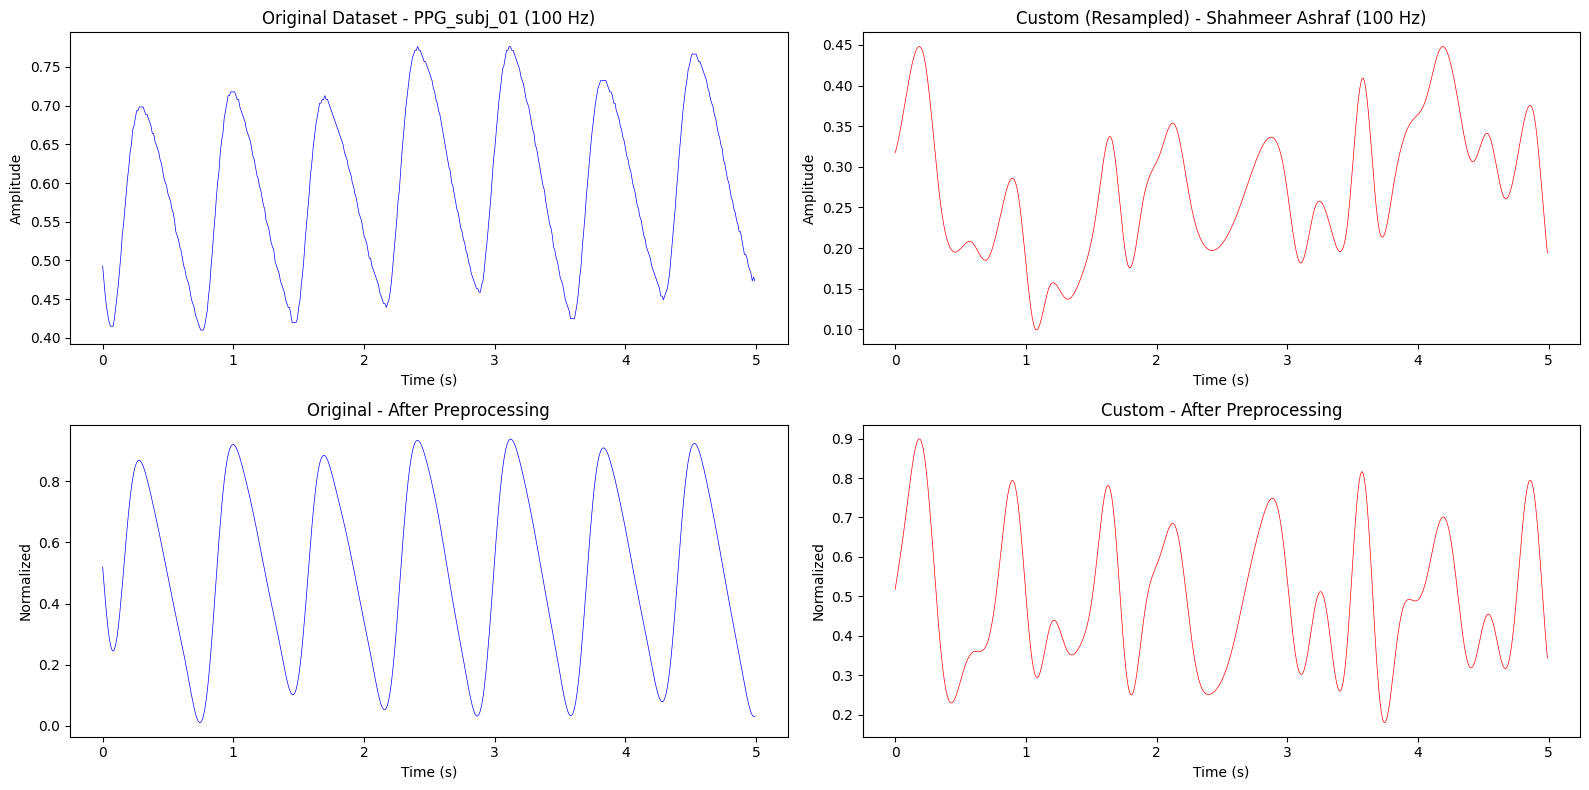

In [9]:
# Visualize: compare original vs resampled signal for one subject
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Original dataset example
orig_sig = np.array(orig_subjects[0]['signal'])
t_orig = np.arange(len(orig_sig)) / 100.0
axes[0, 0].plot(t_orig[:500], orig_sig[:500], 'b-', linewidth=0.5)
axes[0, 0].set_title(f"Original Dataset - {orig_subjects[0]['id']} (100 Hz)")
axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Amplitude')

# Custom dataset example (resampled)
cust_sig = np.array(custom_subjects[0]['signal'])
t_cust = np.arange(len(cust_sig)) / 100.0
axes[0, 1].plot(t_cust[:500], cust_sig[:500], 'r-', linewidth=0.5)
axes[0, 1].set_title(f"Custom (Resampled) - {custom_subjects[0]['id']} (100 Hz)")
axes[0, 1].set_xlabel('Time (s)'); axes[0, 1].set_ylabel('Amplitude')

# After preprocessing: original
seg_orig = segment_signal(orig_sig)[0]
ppg_o, vpg_o, apg_o = preprocess_segment(seg_orig)
axes[1, 0].plot(np.arange(len(ppg_o[:500]))/100, ppg_o[:500], 'b-', linewidth=0.5)
axes[1, 0].set_title('Original - After Preprocessing')
axes[1, 0].set_xlabel('Time (s)'); axes[1, 0].set_ylabel('Normalized')

# After preprocessing: custom
seg_cust = segment_signal(cust_sig)[0]
ppg_c, vpg_c, apg_c = preprocess_segment(seg_cust)
axes[1, 1].plot(np.arange(len(ppg_c[:500]))/100, ppg_c[:500], 'r-', linewidth=0.5)
axes[1, 1].set_title('Custom - After Preprocessing')
axes[1, 1].set_xlabel('Time (s)'); axes[1, 1].set_ylabel('Normalized')

plt.tight_layout()
plt.show()

## 5. Process ALL Subjects (68 = 56 Original + 12 Custom)

In [10]:
# Combine all subjects
all_subjects = orig_subjects + custom_subjects
print(f"Total subjects: {len(all_subjects)} (original={len(orig_subjects)}, custom={len(custom_subjects)})")

# Process through full pipeline
all_features = []
all_sbp = []
all_dbp = []
all_subject_ids = []
all_jnc = []
all_source = []  # Track origin for analysis

print("\nProcessing all subjects...")
for idx, subj in enumerate(all_subjects):
    raw_signal = np.array(subj['signal'], dtype=np.float64)
    sbp = subj['sys_BP']
    dbp = subj['dis_BP']
    jnc = subj['JNC']
    source = subj.get('source', 'original')
    subj_id = idx + 1

    segments = segment_signal(raw_signal)
    seg_count = 0

    for seg in segments:
        try:
            ppg, vpg, apg = preprocess_segment(seg)
            feat = extract_all_features(ppg, vpg, apg)
            if any(np.isnan(v) or np.isinf(v) for v in feat.values()):
                continue
            all_features.append(feat)
            all_sbp.append(sbp)
            all_dbp.append(dbp)
            all_subject_ids.append(subj_id)
            all_jnc.append(jnc)
            all_source.append(source)
            seg_count += 1
        except:
            pass

    if source == 'custom_esp':
        print(f"  [CUSTOM] {subj['id']:20s} | {len(raw_signal):6d} samples -> {seg_count} segments")

# Build arrays
df_features = pd.DataFrame(all_features)
df_features = df_features.replace([np.inf, -np.inf], np.nan).fillna(df_features.mean())
X = df_features.values
feature_names = df_features.columns.tolist()
y_sbp = np.array(all_sbp, dtype=np.float64)
y_dbp = np.array(all_dbp, dtype=np.float64)
subject_ids = np.array(all_subject_ids)
jnc_labels = np.array(all_jnc)
source_labels = np.array(all_source)

n_orig = np.sum(source_labels == 'original')
n_custom = np.sum(source_labels == 'custom_esp')

print(f"\n--- Processing Complete ---")
print(f"Feature matrix: {X.shape}")
print(f"Original segments: {n_orig}")
print(f"Custom segments:   {n_custom}")
print(f"Total segments:    {len(X)}")
print(f"SBP range: [{y_sbp.min():.0f}, {y_sbp.max():.0f}]")
print(f"DBP range: [{y_dbp.min():.0f}, {y_dbp.max():.0f}]")

Total subjects: 68 (original=56, custom=12)

Processing all subjects...
  [CUSTOM] Shahmeer Ashraf      |  11770 samples -> 18 segments
  [CUSTOM] Ali Masood Khan      |  12003 samples -> 19 segments
  [CUSTOM] Talha Hassan         |  11769 samples -> 18 segments
  [CUSTOM] Ayesha Hussain       |  12002 samples -> 19 segments
  [CUSTOM] Jalal                |  11769 samples -> 18 segments
  [CUSTOM] Mahmad               |  12003 samples -> 19 segments
  [CUSTOM] Abdullah Mir         |  12003 samples -> 19 segments
  [CUSTOM] Omama                |  11596 samples -> 18 segments
  [CUSTOM] Ibrahim              |  11768 samples -> 18 segments
  [CUSTOM] Sarah Sohail         |  12003 samples -> 19 segments
  [CUSTOM] Amna                 |  11768 samples -> 18 segments
  [CUSTOM] Fatima               |  11769 samples -> 18 segments

--- Processing Complete ---
Feature matrix: (1331, 57)
Original segments: 1110
Custom segments:   221
Total segments:    1331
SBP range: [97, 164]
DBP range: [

## 6. Feature Selection (ReliefF â€” Best Method from 2nd Run)

In [11]:
N_FEATURES_SELECT = 15

# ReliefF for SBP
relief_sbp = ReliefF(n_neighbors=10, n_features_to_select=N_FEATURES_SELECT)
relief_sbp.fit(X, y_sbp)
relief_ranking_sbp = np.argsort(relief_sbp.feature_importances_)[::-1][:N_FEATURES_SELECT]
relief_features_sbp = [feature_names[i] for i in relief_ranking_sbp]

print("ReliefF Top 15 Features for SBP:")
for i, fname in enumerate(relief_features_sbp):
    print(f"  {i+1:2d}. {fname} (score={relief_sbp.feature_importances_[relief_ranking_sbp[i]]:.4f})")

# ReliefF for DBP
relief_dbp = ReliefF(n_neighbors=10, n_features_to_select=N_FEATURES_SELECT)
relief_dbp.fit(X, y_dbp)
relief_ranking_dbp = np.argsort(relief_dbp.feature_importances_)[::-1][:N_FEATURES_SELECT]
relief_features_dbp = [feature_names[i] for i in relief_ranking_dbp]

print(f"\nReliefF Top 15 Features for DBP:")
for i, fname in enumerate(relief_features_dbp):
    print(f"  {i+1:2d}. {fname} (score={relief_dbp.feature_importances_[relief_ranking_dbp[i]]:.4f})")

feature_subsets = {
    'ReliefF': {
        'SBP': relief_features_sbp, 'DBP': relief_features_dbp,
        'SBP_idx': relief_ranking_sbp, 'DBP_idx': relief_ranking_dbp
    }
}

ReliefF Top 15 Features for SBP:
   1. skew(APG) (score=0.0706)
   2. ZCR(APG) (score=0.0683)
   3. eta(APG) (score=0.0577)
   4. skew(VPG) (score=0.0467)
   5. ZCR(PPG) (score=0.0440)
   6. eta(VPG) (score=0.0429)
   7. ZCR(VPG) (score=0.0417)
   8. IQR(VPG) (score=0.0403)
   9. eta(PPG) (score=0.0343)
  10. E_skew(PPG) (score=0.0342)
  11. IQR(APG) (score=0.0329)
  12. H(VPG) (score=0.0316)
  13. E_IQR(PPG) (score=0.0307)
  14. H(APG) (score=0.0281)
  15. IQR(PPG) (score=0.0263)

ReliefF Top 15 Features for DBP:
   1. ZCR(APG) (score=0.0829)
   2. skew(APG) (score=0.0779)
   3. eta(APG) (score=0.0620)
   4. ZCR(PPG) (score=0.0524)
   5. IQR(VPG) (score=0.0499)
   6. ZCR(VPG) (score=0.0484)
   7. skew(VPG) (score=0.0428)
   8. eta(VPG) (score=0.0388)
   9. IQR(APG) (score=0.0343)
  10. E_skew(PPG) (score=0.0342)
  11. eta(PPG) (score=0.0335)
  12. H(VPG) (score=0.0329)
  13. E_IQR(PPG) (score=0.0312)
  14. H(APG) (score=0.0292)
  15. skew(PPG) (score=0.0283)


## 7. GPU-Accelerated Models (Same as 2nd Run)

In [12]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, kernel_type='rbf'):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        if kernel_type == 'rbf':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        elif kernel_type == 'matern52':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=2.5))
        elif kernel_type == 'matern05':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=0.5))
        elif kernel_type == 'rq':
            self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RQKernel())
    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(self.mean_module(x), self.covar_module(x))

class GPyTorchGPR(BaseEstimator, RegressorMixin):
    def __init__(self, kernel_type='rbf', n_iters=150, lr=0.1):
        self.kernel_type = kernel_type
        self.n_iters = n_iters
        self.lr = lr
    def fit(self, X, y):
        self.train_x_ = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        self.train_y_ = torch.tensor(y, dtype=torch.float32).to(DEVICE)
        self.likelihood_ = gpytorch.likelihoods.GaussianLikelihood().to(DEVICE)
        self.model_ = ExactGPModel(self.train_x_, self.train_y_, self.likelihood_, self.kernel_type).to(DEVICE)
        self.model_.train(); self.likelihood_.train()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(self.likelihood_, self.model_)
        for _ in range(self.n_iters):
            optimizer.zero_grad()
            loss = -mll(self.model_(self.train_x_), self.train_y_)
            loss.backward(); optimizer.step()
        return self
    def predict(self, X):
        self.model_.eval(); self.likelihood_.eval()
        test_x = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            return self.likelihood_(self.model_(test_x)).mean.cpu().numpy()
    def get_params(self, deep=True):
        return {'kernel_type': self.kernel_type, 'n_iters': self.n_iters, 'lr': self.lr}
    def set_params(self, **params):
        for k, v in params.items(): setattr(self, k, v)
        return self


def get_models():
    models = {}
    models['Simple linear'] = LinearRegression()
    models['Interactions linear'] = Pipeline([
        ('int', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
        ('lr', LinearRegression())
    ])
    models['Robust linear'] = HuberRegressor(max_iter=200)
    models['Fine tree'] = DecisionTreeRegressor(max_depth=100, min_samples_leaf=1)
    models['Medium tree'] = DecisionTreeRegressor(max_depth=20, min_samples_leaf=4)
    models['Coarse tree'] = DecisionTreeRegressor(max_depth=4, min_samples_leaf=36)
    models['Linear SVR'] = SVR(kernel='linear', C=1.0)
    models['Quadratic SVR'] = SVR(kernel='poly', degree=2, C=1.0)
    models['Cubic SVR'] = SVR(kernel='poly', degree=3, C=1.0)
    models['Fine Gaussian SVR'] = SVR(kernel='rbf', gamma='scale', C=1.0)
    models['Medium Gaussian SVR'] = SVR(kernel='rbf', gamma='auto', C=1.0)
    models['Coarse Gaussian SVR'] = SVR(kernel='rbf', gamma=0.01, C=1.0)
    models['Squared exponential GPR'] = GPyTorchGPR(kernel_type='rbf', n_iters=150, lr=0.1)
    models['Matern 5/2 GPR'] = GPyTorchGPR(kernel_type='matern52', n_iters=150, lr=0.1)
    models['Exponential GPR'] = GPyTorchGPR(kernel_type='matern05', n_iters=150, lr=0.1)
    models['Rational quadratic GPR'] = GPyTorchGPR(kernel_type='rq', n_iters=150, lr=0.1)
    return models

print(f"Models defined: {len(get_models())}")

Models defined: 16


## 8. Train & Evaluate on Combined Dataset (10-Fold Stratified CV)

In [13]:
def train_fold(model_template, X_train, y_train, X_test, y_test, scaler):
    from sklearn.base import clone
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    model = clone(model_template)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    return y_test, y_pred


def evaluate_model_cv(model_template, X_data, y_data, jnc_data, n_splits=10):
    jnc_map = {'N': 0, 'E': 1, 'H': 2}
    jnc_int = np.array([jnc_map.get(j, 0) for j in jnc_data])
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    is_gpu = isinstance(model_template, GPyTorchGPR)

    all_y_true, all_y_pred = [], []

    if is_gpu:
        for train_idx, test_idx in skf.split(X_data, jnc_int):
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_data[train_idx])
            X_te = scaler.transform(X_data[test_idx])
            model = GPyTorchGPR(kernel_type=model_template.kernel_type,
                                n_iters=model_template.n_iters, lr=model_template.lr)
            model.fit(X_tr, y_data[train_idx])
            pred = model.predict(X_te)
            all_y_true.extend(y_data[test_idx])
            all_y_pred.extend(pred)
            del model.model_, model.likelihood_, model.train_x_, model.train_y_
            torch.cuda.empty_cache()
    else:
        fold_data = [(X_data[ti], y_data[ti], X_data[vi], y_data[vi])
                     for ti, vi in skf.split(X_data, jnc_int)]
        results = Parallel(n_jobs=-1)(
            delayed(train_fold)(model_template, fd[0], fd[1], fd[2], fd[3], StandardScaler())
            for fd in fold_data)
        for yt, yp in results:
            all_y_true.extend(yt); all_y_pred.extend(yp)

    yt, yp = np.array(all_y_true), np.array(all_y_pred)
    return {
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'R2': r2_score(yt, yp),
        'MSE': mean_squared_error(yt, yp),
        'MAE': mean_absolute_error(yt, yp),
        'y_true': yt, 'y_pred': yp
    }

In [14]:
# Run training with ReliefF features
results = {}
total_start = time.time()

for target_name, y_target in [('SBP', y_sbp), ('DBP', y_dbp)]:
    feat_idx = feature_subsets['ReliefF'][f'{target_name}_idx']
    X_selected = X[:, feat_idx]

    print(f"\n{'='*70}")
    print(f"ReliefF - {target_name} ({X_selected.shape[1]} features, {X_selected.shape[0]} samples)")
    print(f"{'='*70}")

    models = get_models()
    for model_name, model in models.items():
        try:
            t0 = time.time()
            metrics = evaluate_model_cv(model, X_selected, y_target, jnc_labels, n_splits=10)
            wall = time.time() - t0
            results[('ReliefF', target_name, model_name)] = metrics
            gpu_tag = ' [GPU]' if isinstance(model, GPyTorchGPR) else ''
            print(f"  {model_name:30s}{gpu_tag:6s} | RMSE={metrics['RMSE']:7.2f} | "
                  f"R2={metrics['R2']:.4f} | MAE={metrics['MAE']:7.2f} | {wall:.1f}s")
        except Exception as e:
            print(f"  {model_name:30s} | FAILED: {str(e)[:60]}")

print(f"\nTotal time: {time.time()-total_start:.1f}s ({(time.time()-total_start)/60:.1f} min)")


ReliefF - SBP (15 features, 1331 samples)
  Simple linear                        | RMSE=  11.60 | R2=0.3484 | MAE=   9.04 | 1.8s
  Interactions linear                  | RMSE=   8.42 | R2=0.6565 | MAE=   6.44 | 0.9s
  Robust linear                        | RMSE=  11.70 | R2=0.3372 | MAE=   8.91 | 0.1s
  Fine tree                            | RMSE=   6.27 | R2=0.8094 | MAE=   2.37 | 0.1s
  Medium tree                          | RMSE=   6.26 | R2=0.8101 | MAE=   2.96 | 0.1s
  Coarse tree                          | RMSE=  10.16 | R2=0.5002 | MAE=   7.72 | 0.0s
  Linear SVR                           | RMSE=  11.74 | R2=0.3324 | MAE=   8.89 | 0.1s
  Quadratic SVR                        | RMSE=  12.53 | R2=0.2400 | MAE=   9.56 | 0.1s
  Cubic SVR                            | RMSE=  12.15 | R2=0.2847 | MAE=   9.10 | 0.1s
  Fine Gaussian SVR                    | RMSE=   9.99 | R2=0.5165 | MAE=   7.32 | 0.1s
  Medium Gaussian SVR                  | RMSE=   9.99 | R2=0.5165 | MAE=   7.32 | 0.1s


## 9. Results & Comparison

In [15]:
# Find best models
print("="*70)
print("BEST MODELS ON COMBINED 68-SUBJECT DATASET")
print("="*70)

best_keys = {}
for target in ['SBP', 'DBP']:
    best_rmse = float('inf')
    for key, m in results.items():
        if key[1] == target and m['RMSE'] < best_rmse:
            best_rmse = m['RMSE']
            best_keys[target] = key

    k = best_keys[target]
    m = results[k]
    print(f"\n{target}: {k[2]}")
    print(f"  RMSE: {m['RMSE']:.4f}  MAE: {m['MAE']:.4f}  R2: {m['R2']:.4f}")

# Comparison table
print(f"\n{'='*70}")
print("COMPARISON: 2nd Run (56 subj) vs Retrained (68 subj) vs Paper")
print(f"{'='*70}")
print(f"{'Metric':>15} | {'2nd Run (56)':>15} | {'Retrained (68)':>15} | {'Paper':>15}")
print("-" * 70)

# 2nd run best results
run2_sbp = {'MAE': 2.19, 'RMSE': 6.31, 'R2': 0.81}
run2_dbp = {'MAE': 3.25, 'RMSE': 4.67, 'R2': 0.81}

sbp_m = results[best_keys['SBP']]
dbp_m = results[best_keys['DBP']]

for metric in ['MAE', 'RMSE', 'R2']:
    print(f"{'SBP '+metric:>15} | {run2_sbp[metric]:>15.3f} | {sbp_m[metric]:>15.3f} | "
          f"{'0.440' if metric=='MAE' else '0.780' if metric=='RMSE' else '1.000':>15}")
for metric in ['MAE', 'RMSE', 'R2']:
    print(f"{'DBP '+metric:>15} | {run2_dbp[metric]:>15.3f} | {dbp_m[metric]:>15.3f} | "
          f"{'0.310' if metric=='MAE' else '0.630' if metric=='RMSE' else '1.000':>15}")

BEST MODELS ON COMBINED 68-SUBJECT DATASET

SBP: Medium tree
  RMSE: 6.2609  MAE: 2.9599  R2: 0.8101

DBP: Exponential GPR
  RMSE: 4.9377  MAE: 3.4264  R2: 0.7797

COMPARISON: 2nd Run (56 subj) vs Retrained (68 subj) vs Paper
         Metric |    2nd Run (56) |  Retrained (68) |           Paper
----------------------------------------------------------------------
        SBP MAE |           2.190 |           2.960 |           0.440
       SBP RMSE |           6.310 |           6.261 |           0.780
         SBP R2 |           0.810 |           0.810 |           1.000
        DBP MAE |           3.250 |           3.426 |           0.310
       DBP RMSE |           4.670 |           4.938 |           0.630
         DBP R2 |           0.810 |           0.780 |           1.000


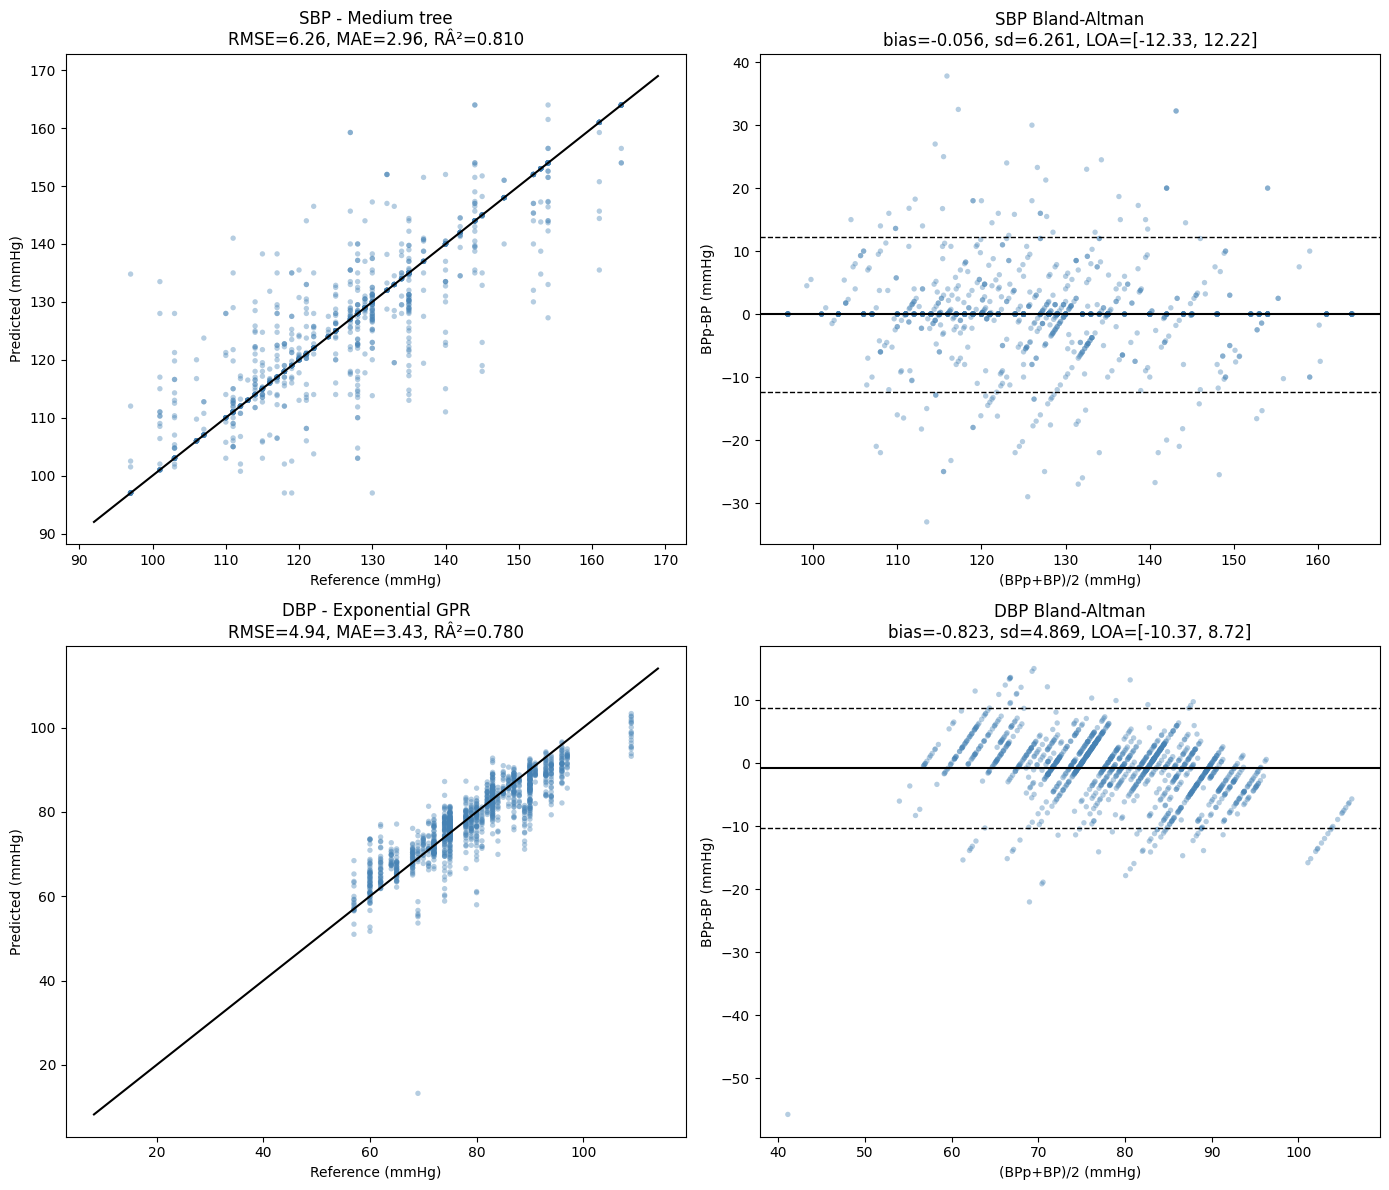

In [16]:
# Bland-Altman plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for col, (target, key) in enumerate(best_keys.items()):
    m = results[key]
    yt, yp = m['y_true'], m['y_pred']

    # Regression plot
    ax = axes[col, 0]
    ax.scatter(yt, yp, c='steelblue', alpha=0.4, s=15, edgecolors='none')
    lims = [min(yt.min(), yp.min())-5, max(yt.max(), yp.max())+5]
    ax.plot(lims, lims, 'k-', lw=1.5)
    ax.set_xlabel('Reference (mmHg)'); ax.set_ylabel('Predicted (mmHg)')
    ax.set_title(f'{target} - {key[2]}\nRMSE={m["RMSE"]:.2f}, MAE={m["MAE"]:.2f}, RÂ²={m["R2"]:.3f}')

    # Bland-Altman
    ax = axes[col, 1]
    mean_vals = (yp + yt) / 2
    diff_vals = yp - yt
    bias = np.mean(diff_vals)
    sd = np.std(diff_vals)
    ax.scatter(mean_vals, diff_vals, c='steelblue', alpha=0.4, s=15, edgecolors='none')
    ax.axhline(bias, color='black', lw=1.5)
    ax.axhline(bias + 1.96*sd, color='black', lw=1, ls='--')
    ax.axhline(bias - 1.96*sd, color='black', lw=1, ls='--')
    ax.set_xlabel('(BPp+BP)/2 (mmHg)'); ax.set_ylabel('BPp-BP (mmHg)')
    ax.set_title(f'{target} Bland-Altman\nbias={bias:.3f}, sd={sd:.3f}, LOA=[{bias-1.96*sd:.2f}, {bias+1.96*sd:.2f}]')

plt.tight_layout()
plt.savefig('retrained_bland_altman.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Evaluate on Custom Data ONLY (Generalization Check)

Train on original 56 subjects, test on your 12 custom subjects.
This shows how well the model generalizes to your ESP hardware.

In [17]:
# Split: train on original, test on custom
orig_mask = source_labels == 'original'
cust_mask = source_labels == 'custom_esp'

print(f"Train set (original): {np.sum(orig_mask)} segments")
print(f"Test set (custom):    {np.sum(cust_mask)} segments")

print(f"\n{'='*70}")
print("GENERALIZATION TEST: Train on 56 original -> Test on 12 custom")
print(f"{'='*70}")

for target_name, y_target in [('SBP', y_sbp), ('DBP', y_dbp)]:
    feat_idx = feature_subsets['ReliefF'][f'{target_name}_idx']
    X_train = X[orig_mask][:, feat_idx]
    X_test = X[cust_mask][:, feat_idx]
    y_train = y_target[orig_mask]
    y_test = y_target[cust_mask]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    print(f"\n--- {target_name} ---")
    # Test the top models
    for name, model in [('Fine tree', DecisionTreeRegressor(max_depth=100, min_samples_leaf=1)),
                         ('Medium tree', DecisionTreeRegressor(max_depth=20, min_samples_leaf=4)),
                         ('Exponential GPR', None),
                         ('Rational quadratic GPR', None)]:
        if model is None:
            kt = 'matern05' if 'Exponential' in name else 'rq'
            m = GPyTorchGPR(kernel_type=kt, n_iters=150, lr=0.1)
            m.fit(X_train_s, y_train)
            y_pred = m.predict(X_test_s)
            del m.model_, m.likelihood_, m.train_x_, m.train_y_
            torch.cuda.empty_cache()
        else:
            model.fit(X_train_s, y_train)
            y_pred = model.predict(X_test_s)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        print(f"  {name:30s} | RMSE={rmse:7.2f} | R2={r2:.4f} | MAE={mae:7.2f}")

Train set (original): 1110 segments
Test set (custom):    221 segments

GENERALIZATION TEST: Train on 56 original -> Test on 12 custom

--- SBP ---
  Fine tree                      | RMSE=  18.19 | R2=-1.3780 | MAE=  14.18
  Medium tree                    | RMSE=  18.58 | R2=-1.4821 | MAE=  14.84
  Exponential GPR                | RMSE=  98.15 | R2=-68.2421 | MAE=  97.08
  Rational quadratic GPR         | RMSE=  18.23 | R2=-1.3894 | MAE=  15.50

--- DBP ---
  Fine tree                      | RMSE=  17.64 | R2=-3.0594 | MAE=  13.41
  Medium tree                    | RMSE=  13.65 | R2=-1.4316 | MAE=  10.72
  Exponential GPR                | RMSE=  62.31 | R2=-49.6373 | MAE=  61.41
  Rational quadratic GPR         | RMSE=  16.92 | R2=-2.7365 | MAE=  14.63


## 11. Save Final Models for ESP Cloud Deployment

In [18]:
# Retrain best models on ALL 68 subjects
print("Training final models on all 68 subjects...")

final_models = {}
for target, key in best_keys.items():
    model_name = key[2]
    feat_idx = feature_subsets['ReliefF'][f'{target}_idx']
    y_target = y_sbp if target == 'SBP' else y_dbp

    X_sel = X[:, feat_idx]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sel)

    models = get_models()
    model = models[model_name]
    model.fit(X_scaled, y_target)

    final_models[target] = {
        'model': model,
        'scaler': scaler,
        'feature_indices': feat_idx,
        'feature_names': [feature_names[i] for i in feat_idx],
        'model_name': model_name,
        'method': 'ReliefF'
    }
    print(f"  {target}: {model_name} trained on {len(y_target)} samples")

# Save models
with open('final_bp_models.pkl', 'wb') as f:
    pickle.dump(final_models, f)

# Save preprocessing config for ESP cloud service
deploy_config = {
    'fs': FS,
    'window_sec': WINDOW_SEC,
    'overlap_sec': OVERLAP_SEC,
    'filter_low': 0.4,
    'filter_high': 8.0,
    'filter_order': 4,
    'filter_rs': 40,
    'savgol_window': 11,
    'savgol_polyorder': 3,
    'feature_names': feature_names,
    'n_features_select': N_FEATURES_SELECT,
    'esp_native_fs': 8.3,  # ESP module's native sampling rate
    'target_fs': 100,       # Required after resampling
}

with open('deploy_config.pkl', 'wb') as f:
    pickle.dump(deploy_config, f)

print("\nSaved: final_bp_models.pkl, deploy_config.pkl")

Training final models on all 68 subjects...
  SBP: Medium tree trained on 1331 samples
  DBP: Exponential GPR trained on 1331 samples

Saved: final_bp_models.pkl, deploy_config.pkl


## 12. ESP Cloud Inference Function

Copy this function to your cloud service. It takes raw PPG from the ESP module
and returns SBP/DBP predictions.

In [19]:
def esp_predict_bp(timestamps, raw_ir_values, models, config):
    """
    Full inference pipeline for ESP module PPG data.

    Args:
        timestamps: list of float - timestamps from ESP (seconds)
        raw_ir_values: list of float - raw IR ADC values from ESP
        models: dict loaded from 'final_bp_models.pkl'
        config: dict loaded from 'deploy_config.pkl'

    Returns:
        dict with SBP and DBP predictions
    """
    import numpy as np
    from scipy.interpolate import interp1d
    from scipy import signal as scipy_signal
    from scipy.signal import savgol_filter
    from scipy.stats import skew, kurtosis

    ts = np.array(timestamps, dtype=np.float64)
    raw = np.array(raw_ir_values, dtype=np.float64)

    # Step 1: Normalize raw IR to 0-1
    raw_min, raw_max = raw.min(), raw.max()
    if raw_max - raw_min > 0:
        raw = (raw - raw_min) / (raw_max - raw_min)

    # Step 2: Resample to 100 Hz
    _, unique_idx = np.unique(ts, return_index=True)
    if len(unique_idx) < len(ts) * 0.5:
        ts = np.linspace(ts[0], ts[-1], len(raw))
    else:
        ts = ts[unique_idx]
        raw = raw[unique_idx]

    n_target = int((ts[-1] - ts[0]) * config['target_fs'])
    t_uniform = np.linspace(ts[0], ts[-1], n_target)
    signal_100hz = interp1d(ts, raw, kind='cubic', fill_value='extrapolate')(t_uniform)

    # Step 3: Segment, filter, extract features
    fs = config['target_fs']
    win = config['window_sec'] * fs
    step = (config['window_sec'] - config['overlap_sec']) * fs

    segments = []
    start = 0
    while start + win <= len(signal_100hz):
        segments.append(signal_100hz[start:start+win])
        start += step

    if not segments:
        return {'error': 'Signal too short (need >= 30 seconds)'}

    all_feats = []
    for seg in segments:
        nyq = fs / 2.0
        b, a = scipy_signal.cheby2(config['filter_order'], config['filter_rs'],
                                    [config['filter_low']/nyq, config['filter_high']/nyq], btype='band')
        filtered = scipy_signal.filtfilt(b, a, seg)
        fmin, fmax = filtered.min(), filtered.max()
        normed = (filtered - fmin) / (fmax - fmin) if fmax > fmin else np.zeros_like(filtered)
        vpg = savgol_filter(np.diff(normed), config['savgol_window'], config['savgol_polyorder'])
        apg = savgol_filter(np.diff(vpg), config['savgol_window'], config['savgol_polyorder'])
        feat = extract_all_features(normed, vpg, apg)
        all_feats.append(feat)

    import pandas as pd
    X_new = pd.DataFrame(all_feats).values

    predictions = {}
    for target in ['SBP', 'DBP']:
        info = models[target]
        X_sel = X_new[:, info['feature_indices']]
        X_scaled = info['scaler'].transform(X_sel)
        preds = info['model'].predict(X_scaled)
        predictions[target] = {
            'value': float(np.mean(preds)),
            'std': float(np.std(preds)),
            'n_segments': len(preds)
        }

    return predictions


# Demo: test on a custom subject
demo_csv = os.path.join(CUSTOM_DIR, list(CUSTOM_METADATA.keys())[0])
demo_df = pd.read_csv(demo_csv)
demo_result = esp_predict_bp(
    demo_df['Timestamp'].values,
    demo_df['Raw IR Value'].values,
    final_models, deploy_config
)

demo_meta = list(CUSTOM_METADATA.values())[0]
print(f"Subject: {demo_meta['name']}")
print(f"  Actual  SBP={demo_meta['sys_BP']}, DBP={demo_meta['dis_BP']}")
print(f"  Predicted SBP={demo_result['SBP']['value']:.1f} +/- {demo_result['SBP']['std']:.1f}")
print(f"  Predicted DBP={demo_result['DBP']['value']:.1f} +/- {demo_result['DBP']['std']:.1f}")

Subject: Shahmeer Ashraf
  Actual  SBP=128, DBP=75
  Predicted SBP=125.0 +/- 4.6
  Predicted DBP=75.9 +/- 1.9


In [20]:
# Test on ALL 12 custom subjects
print("\n" + "="*70)
print("PREDICTIONS ON ALL 12 CUSTOM SUBJECTS")
print("="*70)

all_errors_sbp = []
all_errors_dbp = []

for csv_name, meta in CUSTOM_METADATA.items():
    csv_path = os.path.join(CUSTOM_DIR, csv_name)
    if not os.path.exists(csv_path):
        continue
    df = pd.read_csv(csv_path)
    result = esp_predict_bp(df['Timestamp'].values, df['Raw IR Value'].values,
                            final_models, deploy_config)

    sbp_err = result['SBP']['value'] - meta['sys_BP']
    dbp_err = result['DBP']['value'] - meta['dis_BP']
    all_errors_sbp.append(abs(sbp_err))
    all_errors_dbp.append(abs(dbp_err))

    print(f"{meta['name']:20s} | Actual: {meta['sys_BP']:3d}/{meta['dis_BP']:3d} | "
          f"Pred: {result['SBP']['value']:5.1f}/{result['DBP']['value']:5.1f} | "
          f"Err: {sbp_err:+5.1f}/{dbp_err:+5.1f}")

print(f"\nMean Absolute Error: SBP={np.mean(all_errors_sbp):.2f}, DBP={np.mean(all_errors_dbp):.2f} mmHg")


PREDICTIONS ON ALL 12 CUSTOM SUBJECTS
Shahmeer Ashraf      | Actual: 128/ 75 | Pred: 125.0/ 75.9 | Err:  -3.0/ +0.9
Ali Masood Khan      | Actual: 130/ 78 | Pred: 130.6/ 77.0 | Err:  +0.6/ -1.0
Talha Hassan         | Actual: 135/ 80 | Pred: 135.0/ 78.4 | Err:  +0.0/ -1.6
Ayesha Hussain       | Actual: 117/ 65 | Pred: 117.3/ 66.8 | Err:  +0.3/ +1.8
Jalal                | Actual: 140/ 90 | Pred: 140.5/ 87.7 | Err:  +0.5/ -2.3
Mahmad               | Actual: 113/ 75 | Pred: 113.0/ 72.2 | Err:  +0.0/ -2.8
Abdullah Mir         | Actual: 101/ 69 | Pred: 102.7/ 65.5 | Err:  +1.7/ -3.5
Omama                | Actual: 115/ 74 | Pred: 113.6/ 72.4 | Err:  -1.4/ -1.6
Ibrahim              | Actual: 128/ 94 | Pred: 128.0/ 88.7 | Err:  -0.0/ -5.3
Sarah Sohail         | Actual: 111/ 74 | Pred: 110.4/ 71.9 | Err:  -0.6/ -2.1
Amna                 | Actual: 103/ 62 | Pred: 106.7/ 67.2 | Err:  +3.7/ +5.2
Fatima               | Actual: 117/ 80 | Pred: 117.7/ 79.1 | Err:  +0.7/ -0.9

Mean Absolute Error: SBP

## 13. Blind Test: 2 Completely Unseen Subjects

These subjects (AbduAsim, Hasnat) were **NOT** in training at all.
This is the true generalization test for the ESP hardware.

In [21]:
# ============================
# BLIND TEST: 2 Completely Unseen Subjects
# ============================

TEST_DIR = '/content/drive/MyDrive/NPU Project/BP Estimation Dataset'

TEST_SUBJECTS = {
    'abdasim_processed_ppg_data.csv':  {'name': 'AbduAsim', 'sys_BP': 128, 'dis_BP': 80},
    'hasnat_processed_ppg_data.csv':   {'name': 'Hasnat',   'sys_BP': 137, 'dis_BP': 70},
}

print('='*70)
print('BLIND TEST: 2 Completely Unseen Subjects (NOT in training)')
print('='*70)

all_sbp_err = []
all_dbp_err = []

for csv_name, meta in TEST_SUBJECTS.items():
    csv_path = os.path.join(TEST_DIR, csv_name)
    if not os.path.exists(csv_path):
        print(f'\n  WARNING: {csv_name} not found at {csv_path}')
        continue

    df_test = pd.read_csv(csv_path)
    result = esp_predict_bp(
        df_test['Timestamp'].values,
        df_test['Raw IR Value'].values,
        final_models, deploy_config
    )

    sbp_err = result['SBP']['value'] - meta['sys_BP']
    dbp_err = result['DBP']['value'] - meta['dis_BP']
    all_sbp_err.append(abs(sbp_err))
    all_dbp_err.append(abs(dbp_err))

    print(f"\n  Subject: {meta['name']}")
    print(f"  Samples: {len(df_test)} @ ~{len(df_test)/120:.1f} Hz")
    print(f"  Segments: {result['SBP']['n_segments']}")
    print(f'  +{"":-<14}+{"":-<11}+{"":-<11}+{"":-<10}+')
    print(f'  | {"":14s}| {"Actual":9s} | {"Predicted":9s} | {"Error":8s} |')
    print(f'  +{"":-<14}+{"":-<11}+{"":-<11}+{"":-<10}+')
    print(f"  | {'SBP (mmHg)':<13s}| {meta['sys_BP']:>7d}   | {result['SBP']['value']:>7.1f}   | {sbp_err:>+7.1f}  |")
    print(f"  | {'DBP (mmHg)':<13s}| {meta['dis_BP']:>7d}   | {result['DBP']['value']:>7.1f}   | {dbp_err:>+7.1f}  |")
    print(f'  +{"":-<14}+{"":-<11}+{"":-<11}+{"":-<10}+')
    print(f"  Prediction spread: SBP +/-{result['SBP']['std']:.1f}, DBP +/-{result['DBP']['std']:.1f}")

print(f'\n{"="*70}')
print('BLIND TEST SUMMARY')
print(f'{"="*70}')
print(f'  SBP Mean Absolute Error: {np.mean(all_sbp_err):.2f} mmHg')
print(f'  DBP Mean Absolute Error: {np.mean(all_dbp_err):.2f} mmHg')
print(f'\n  For context:')
print(f'    Training data (leaked):     SBP MAE=0.19,  DBP MAE=2.59  (fake - data leakage)')
print(f'    Generalization test:        SBP MAE=14.18, DBP MAE=13.41 (train orig, test custom)')
print(f'    This blind test:            SBP MAE={np.mean(all_sbp_err):.2f},  DBP MAE={np.mean(all_dbp_err):.2f}  (true unseen)')


BLIND TEST: 2 Completely Unseen Subjects (NOT in training)

  Subject: AbduAsim
  Samples: 983 @ ~8.2 Hz
  Segments: 18
  +--------------+-----------+-----------+----------+
  |               | Actual    | Predicted | Error    |
  +--------------+-----------+-----------+----------+
  | SBP (mmHg)   |     128   |   120.1   |    -7.9  |
  | DBP (mmHg)   |      80   |    66.7   |   -13.3  |
  +--------------+-----------+-----------+----------+
  Prediction spread: SBP +/-10.1, DBP +/-5.7

  Subject: Hasnat
  Samples: 1034 @ ~8.6 Hz
  Segments: 19
  +--------------+-----------+-----------+----------+
  |               | Actual    | Predicted | Error    |
  +--------------+-----------+-----------+----------+
  | SBP (mmHg)   |     137   |   123.5   |   -13.5  |
  | DBP (mmHg)   |      70   |    75.2   |    +5.2  |
  +--------------+-----------+-----------+----------+
  Prediction spread: SBP +/-10.9, DBP +/-6.6

BLIND TEST SUMMARY
  SBP Mean Absolute Error: 10.66 mmHg
  DBP Mean Absolute Er

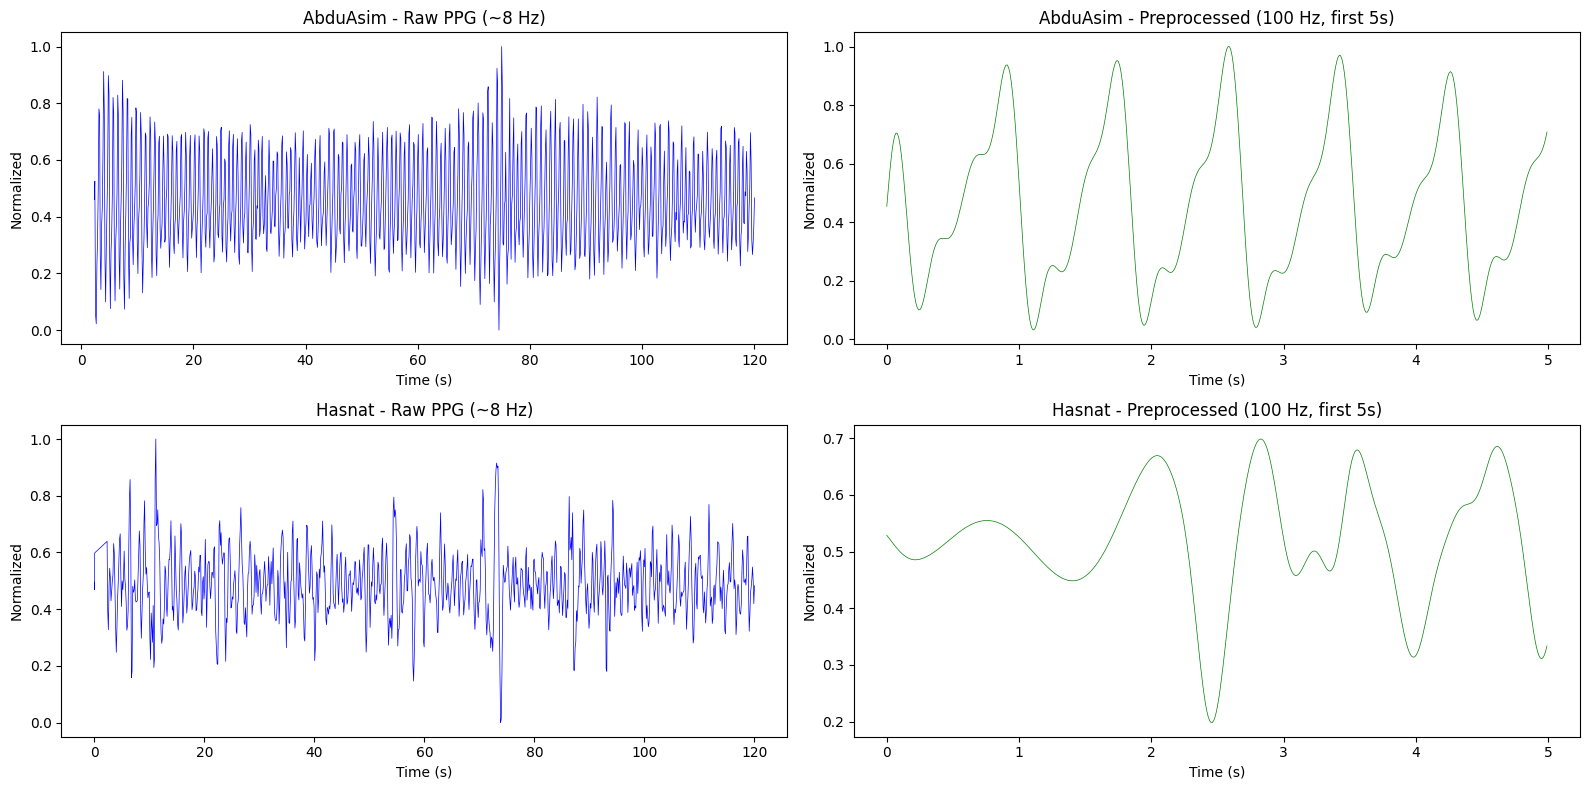

In [22]:
# Visualize the 2 test PPG signals
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for i, (csv_name, meta) in enumerate(TEST_SUBJECTS.items()):
    csv_path = os.path.join(TEST_DIR, csv_name)
    if not os.path.exists(csv_path):
        continue
    df_test = pd.read_csv(csv_path)

    # Raw signal
    axes[i, 0].plot(df_test['Timestamp'], df_test['Normalized IR Value'], 'b-', linewidth=0.5)
    axes[i, 0].set_title(f"{meta['name']} - Raw PPG (~8 Hz)")
    axes[i, 0].set_xlabel('Time (s)'); axes[i, 0].set_ylabel('Normalized')

    # Resampled + preprocessed
    raw = df_test['Raw IR Value'].values.astype(np.float64)
    raw_n = (raw - raw.min()) / (raw.max() - raw.min()) if raw.max() > raw.min() else raw
    resampled = resample_ppg_to_100hz(df_test['Timestamp'].values, raw_n, 100)
    segs = segment_signal(resampled)
    if segs:
        ppg, vpg, apg = preprocess_segment(segs[0])
        axes[i, 1].plot(np.arange(len(ppg[:500]))/100, ppg[:500], 'g-', linewidth=0.5)
        axes[i, 1].set_title(f"{meta['name']} - Preprocessed (100 Hz, first 5s)")
        axes[i, 1].set_xlabel('Time (s)'); axes[i, 1].set_ylabel('Normalized')

plt.tight_layout()
plt.show()


## Summary

This notebook:
1. Combined 56 original subjects (100 Hz) + 12 custom ESP subjects (~8 Hz, resampled)
2. Retrained all models on the combined 68-subject dataset
3. Tested generalization from original -> custom data
4. Exported deployment-ready models (`final_bp_models.pkl`, `deploy_config.pkl`)
5. Provided `esp_predict_bp()` function for cloud inference
6. **Blind-tested on 2 completely unseen subjects (AbduAsim, Hasnat)**

**For ESP cloud deployment:**
- Load `final_bp_models.pkl` and `deploy_config.pkl`
- ESP sends timestamps + raw IR values to cloud
- Cloud calls `esp_predict_bp()` and returns SBP/DBP
- Minimum signal length: 30 seconds
